<a href="https://colab.research.google.com/github/emmanuel-mukira/EY-AI-data-challenge/blob/main/GETTING_STARTED_NOTEBOOK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting Started with Snowflake Notebooks

Welcome to the 2026 EY Data & AI Challenge!

This notebook will get you up and running with Snowflake Notebooks. By the end, you'll see how Snowflake can help you leverage a powerful cloud-computing environment to gather satellite imagery data from an external source and conduct geospatial analyses using that data. Once you successfully run this notebook, you will understand the steps required to use Python notebooks for the data challenge. Dive in and have fun !!!

In [ ]:
!unzip EY-AI-data-challenge.zip

Archive:  EY-AI-data-challenge.zip
   creating: EY-AI-data-challenge/
  inflating: EY-AI-data-challenge/Snowflake Notebooks Package.zip  
  inflating: EY-AI-data-challenge/snowflake_setup.sql  
  inflating: EY-AI-data-challenge/BENCHMARK_MODEL_NOTEBOOK_SNOWFLAKE.ipynb  
  inflating: EY-AI-data-challenge/LANDSAT_DATA_EXTRACTION_NOTEBOOK_SNOWFLAKE.ipynb  
  inflating: EY-AI-data-challenge/LANDSAT_DEMONSTRATION_NOTEBOOK_SNOWFLAKE.ipynb  
  inflating: EY-AI-data-challenge/roadmap.md  
   creating: EY-AI-data-challenge/Snowflake Notebooks Package/
  inflating: EY-AI-data-challenge/Snowflake Notebooks Package/GETTING_STARTED_NOTEBOOK.ipynb  
  inflating: EY-AI-data-challenge/Snowflake Notebooks Package/LANDSAT_DATA_EXTRACTION_NOTEBOOK_SNOWFLAKE.ipynb  
  inflating: EY-AI-data-challenge/Snowflake Notebooks Package/LANDSAT_DEMONSTRATION_NOTEBOOK_SNOWFLAKE.ipynb  
  inflating: EY-AI-data-challenge/Snowflake Notebooks Package/landsat_features_training.csv  
  inflating: EY-AI-data-challenge/Snow

In [ ]:
# Install packages (will work perfectly in Colab)
!pip install pystac_client planetary_computer odc-stac rioxarray geopandas shapely rasterio matplotlib seaborn scikit-learn xgboost

# Navigate to your notebook
%cd /content/EY-AI-data-challenge/Snowflake\ Notebooks\ Package/

# Open and run GETTING_STARTED_NOTEBOOK.ipynb

/content/EY-AI-data-challenge/Snowflake Notebooks Package


In [ ]:
# After satellite data works, save your features
import pandas as pd

# Example: Save processed satellite features
features_df = pd.DataFrame({
    'site_id': site_ids,
    'date': dates,
    'ndvi': ndvi_values,
    'ndwi': ndwi_values,
    'elevation': elevations,
    'distance_to_coast': distances
})

# Save to CSV for Snowflake upload
features_df.to_csv('satellite_features.csv', index=False)
from google.colab import files
files.download('satellite_features.csv')

NameError: name 'site_ids' is not defined

In [ ]:
# In Colab, connect to Snowflake to upload data
# For Snowflake connection, you need your actual credentials
from snowflake.snowpark import Session

# Replace with your actual Snowflake account info
connection_params = {
    "account": "jfecknb-lwb72940",  # e.g., "xy12345.eu-central-1"
    "user": "EMMANUELMUKIRA",
    "password": "qikcox-kifxe4-xodqIn",  # Consider using private key instead
    "warehouse": "COMPUTE_WH",
    "database": "USER$EMMANUELMUKIRA",
    "schema": "PUBLIC"
}

# Only connect if you have real credentials
try:
    session = Session.builder.configs(connection_params).create()
    print("✅ Connected to Snowflake!")
except Exception as e:
    print(f"❌ Snowflake connection failed: {e}")
    print("Please update your connection parameters")


✅ Connected to Snowflake!


In [ ]:
from snowflake.snowpark.context import get_active_session
session = get_active_session()

print("✅ Snowflake session ready!")

✅ Snowflake session ready!


In [ ]:
USE DATABASE "USER$EMMANUELMUKIRA";
USE SCHEMA PUBLIC;

SyntaxError: invalid syntax (ipython-input-262451106.py, line 1)

## Confirm setup of External Access Integration (EAI)

Before running this notebook, you will need to run a SQL script to create an [External Access Integration](https://docs.snowflake.com/en/developer-guide/external-network-access/external-network-access-overview).

This script creates external network access to install PyPI packages and access Planetary Computer API endpoints.

The setup script can be accessed directly within Snowflake using this [deeplink](https://app.snowflake.com/templates?template=setup_account_data_challenge_template).

The SQL script is also located in the Snowflake-Labs repo on [Github](https://github.com/Snowflake-Labs/sfquickstarts/tree/master/site/sfguides/src/ey-ai-and-data-challenge).

An EAI relies upon network rules that are stored in a database. You can attach many rules to the same policy. This same process can be used to setup other access points for external datasets from Google or Amazon.

Snowflake notebooks can run SQL and Python cells. When you run the next cell, you should see a dialog box where you can choose which External Access Integration you wish to use. Select "DATA_CHALLENGE_EXTERNAL_ACCESS". Click "Create and Connect." It will take 2-3 minutes for the kernel to connect to the container service.

When you see that the kernel status is "Connected", then the SQL cell will run, and "DATA_CHALLENGE_EXTERNAL_ACCESS" will be listed in the output.

In [ ]:
# Install all the satellite data packages
!pip install pystac_client planetary_computer odc-stac rioxarray geopandas shapely rasterio matplotlib seaborn scikit-learn xgboost pandas numpy tqdm

# Additional packages for the challenge
!pip install snowflake-connector-python snowflake-snowpark-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.9 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 890.7 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 42.5

In [ ]:
import pystac_client
import planetary_computer as pc
from odc.stac import stac_load
import matplotlib.pyplot as plt

# Test Planetary Computer access
stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# Search for sample data (South Africa region from the notebook)
search = stac.search(
    collections=["landsat-c2-l2"],
    bbox=[28.4, -27.4, 28.6, -27.2],  # Sample region
    datetime="2015-01-01/2015-05-01",
    query={"platform": {"in": ["landsat-7", "landsat-8"]}, "eo:cloud_cover": {"lt": 10}},
)

items = list(search.get_all_items())
print(f"Found {len(items)} Landsat scenes")

Found 6 Landsat scenes


/usr/local/lib/python3.12/dist-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


In [ ]:
# Test that all critical packages work
import pystac_client
import planetary_computer as pc
from odc.stac import stac_load
import rioxarray
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("✅ All packages imported successfully!")

# Test Planetary Computer connection
try:
    stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    print("✅ Planetary Computer API connected!")

    # Quick test search
    search = stac.search(
        collections=["landsat-c2-l2"],
        bbox=[28.4, -27.4, 28.6, -27.2],  # Small test region
        datetime="2020-01-01/2020-01-31",
        query={"platform": {"in": ["landsat-8"]}, "eo:cloud_cover": {"lt": 10}},
        limit=1  # Just get 1 for testing
    )

    items = list(search.get_all_items())
    print(f"✅ Found {len(items)} Landsat scenes (test successful)")

except Exception as e:
    print(f"❌ Error: {e}")

ModuleNotFoundError: No module named 'pystac_client'

In [ ]:
show integrations;

SyntaxError: invalid syntax (ipython-input-1513134058.py, line 1)

## Import Python packages
Snowflake Notebooks have 2 runtime options: On Warehouse or On Container.
When you run Snowflake Notebooks inside Snowflake Workspaces, notebooks run on Container, so you can easily use "pip install" to load python libraries.

The Container runtime contains Streamlit and many other third-party packages (by default)[https://docs.snowflake.com/en/developer-guide/snowflake-ml/container-runtime-ml#snowflake-runtime-packages].

You can add any additional packages from [PyPI- Python Package Index](www.pypi.org) by loading all dependencies in a **requirements.txt** file. You can create the file by running the Python cell below, or manually upload your **requirements.txt** file into the same folder as this notebook using the plus button in the left sidebar.

In [ ]:
from snowflake.snowpark.context import get_active_session
session = get_active_session()

# Step 1: Create the requirements.txt file locally
requirements = """
rioxarray==0.17.0
pystac==1.11.0
pystac_client==0.9.0
planetary_computer==1.0.0
odc-stac==0.3.10
shapely==2.1.1
rasterio==1.4.3
tqdm==4.66.5
pandas==2.3.0
xarray==2025.3.1
matplotlib==3.10.3
geopandas==1.1.1
seaborn==0.13.2
scikit-learn==1.5.2
netCDF4==1.7.2
adlfs==2025.8.0
zarr==2.17.2
dask==2024.10.0
xarray[complete]
numcodecs==0.12.1
"""

with open('/tmp/requirements.txt', 'w') as f:
    f.write(requirements)

print("File created locally")

# Step 2: Upload to notebook stage using SQL

session.sql(f"""
    PUT file:///tmp/requirements.txt
    snow://workspace/USER$.PUBLIC.DEFAULT$/versions/live/
    AUTO_COMPRESS=FALSE
    OVERWRITE=TRUE
""").collect()

print("Uploaded to notebook environment! Refresh your browser tab to see in sidebar.")

File created locally
Uploaded to notebook environment! Refresh your browser tab to see in sidebar.


## Python Package Management

Snowflake Notebooks operate similar to Jupyter notebooks that run in your local environment, with one significant difference in the way storage is handled.

When you run "pip install" in your local environment, there is a physical folder structure where the packages are stored. In Snowflake, there are 2 storage layers: the persistent storage layer (that you can see in the sidebar to the left) and the container storage layer that resets each time your Notebook Container Service restarts.

By default, the Notebook Service has an idle timeout of 24 hours, but the Compute Pool (which uses Snowflake Credits) has an idle timeout of 5 minutes. This means that after 5 minutes, you stop using up your Snowflake Credits, but the variables and packages in the kernel will remain active for 24 hours. For more information, read the [Snowflake Docs](https://docs.snowflake.com/en/user-guide/ui-snowsight/notebooks-in-workspaces/notebooks-in-workspaces-compute-setup).

In [ ]:
import time

start_time = time.time()
print("Installing packages to shared directory...")
print("This may take a few minutes...\n")

# Install all packages from requirements.txt to the shared directory
!pip install uv
!uv pip install  -r requirements.txt

elapsed_time = time.time() - start_time
print(f"\n✓ Package installation complete!")
print(f"  Time elapsed: {elapsed_time:.1f} seconds ({elapsed_time/60:.1f} minutes)")

Installing packages to shared directory...
This may take a few minutes...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 28.8 MB/s eta 0:00:00
Using Python 3.12.12 environment at: /usr
Resolved 114 packages in 2.08s
Prepared 37 packages in 3.08s
Uninstalled 12 packages in 288ms
Installed 37 packages in 223ms
 + adlfs==2025.8.0
 + asciitree==0.3.3
 + azure-core==1.38.1
 + azure-datalake-store==0.0.53
 + azure-identity==1.25.2
 + azure-storage-blob==12.28.0
 + cartopy==0.25.0
 + cftime==1.6.5
 - dask==2025.12.0
 + dask==2024.10.0
 + dask-expr==1.1.16
 + distributed==2024.10.0
 + fasteners==0.20
 + flox==0.11.1
 - geopandas==1.1.2
 + geopandas==1.1.1
 + isodate==0.7.2
 + lz4==4.4.5
 - matplotlib==3.10.0
 + matplotlib==3.10.3
 + msal==1.34.0
 + msal-extensions==1.3.1
 + nc-time-axis==1.4.1
 + netcdf4==1.7.2
 + numbagg==0.9.4
 + numcodecs==0.12.1
 + numpy-groupies==0.11.3
 - odc-stac==0.5.2
 + odc-stac==0.3.10
 - pandas==2.2.2
 + pandas==2.3.0
 - pystac==1.14.3
 + pystac==1.11.0


## Restart Kernel

After installing packages, it is necessary to restart the kernel, to access the new python packages.
Click the "⌄" symbol next to the  "Connect/Connected" button at the top of the editing pane in [Snowflake Workspaces](https://docs.snowflake.com/en/user-guide/ui-snowsight/notebooks-in-workspaces/notebooks-in-workspaces-overview).

## Load Python Dependencies


In [ ]:
# Import common GIS tools
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Import Planetary Computer tools
import pystac_client
import planetary_computer as pc
from odc.stac import stac_load

import dask
import dask.array as da

# Load the satellite data
First, we define our area of interest using latitude and longitude coordinates of the centroid. Then we define the size of the surrounding bounding box (in degrees). Finally, we define the time window.

In [ ]:
# Sample region in South Africa
# Contains Water Quality Sample Site #184 and #186 on the Wilge River
lat_long = (-27.2923, 28.5365) # Lat-Lon centroid location
box_size_deg = 0.15 # Surrounding box in degrees

In [ ]:
# Calculate the Lat-Lon bounding box region
min_lon = lat_long[1]-box_size_deg/2
min_lat = lat_long[0]-box_size_deg/2
max_lon = lat_long[1]+box_size_deg/2
max_lat = lat_long[0]+box_size_deg/2
bounds = (min_lon, min_lat, max_lon, max_lat)

In [ ]:
# Define the time window
time_window="2015-01-01/2015-05-01"

Using the `pystac_client` we can search the Microsoft Planetary Computer's STAC catalog for items matching our query parameters. The result is the number of scenes matching our search criteria that touch our area of interest. Some of these may be partial scenes and may contain clouds. We have included both Landsat-7 and Landsat-8 data and filtered for low-cloud (<10%) scenes.

In [ ]:
stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
search = stac.search(
    collections=["landsat-c2-l2"],
    bbox=bounds,
    datetime=time_window,
    query={"platform": {"in": ["landsat-7", "landsat-8"]}, "eo:cloud_cover": {"lt": 10}},
)
items = list(search.get_all_items())
print('This is the number of scenes that touch our region:',len(items))

This is the number of scenes that touch our region: 6


/usr/local/lib/python3.12/dist-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


Next, we'll load the data into an [xarray](https://xarray.pydata.org/en/stable/) DataArray using the Open Data Cube (ODC) STAC [odc-stac](https://odc-stac.readthedocs.io/en/latest/index.html) library. The ODC [odc](https://www.opendatacube.org) is an open source geospatial data management and analysis software project that is used globally for many projects (e.g., Digital Earth Africa). The ODC-STAC code will load the selected items from the catalog search, select the desired spectral bands, including the "qa_pixel" cloud filtering band, reproject into Lat-Lon coordinates (EPSG:4326) at 30-meters resolution (typical of Landsat pixel resolution), and clip the region to the spatial bounding box.

In [ ]:
# Define the pixel resolution for the final product
# Define the scale according to our selected crs, so we will use degrees
resolution = 30  # meters per pixel
scale = resolution / 111320.0 # degrees per pixel for CRS:4326

In [ ]:
# Define the region and resolution (from earlier cells in the notebook)
import numpy as np

# Sample region in South Africa (from the notebook)
lat_long = (-27.2923, 28.5365)  # Lat-Lon centroid location
box_size_deg = 0.15  # Surrounding box in degrees

# Calculate the Lat-Lon bounding box region
min_lon = lat_long[1]-box_size_deg/2
min_lat = lat_long[0]-box_size_deg/2
max_lon = lat_long[1]+box_size_deg/2
max_lat = lat_long[0]+box_size_deg/2
bounds = (min_lon, min_lat, max_lon, max_lat)

# Define the pixel resolution
resolution = 30  # meters per pixel
scale = resolution / 111320.0  # degrees per pixel for CRS:4326

# Define the time window
time_window = "2015-01-01/2015-05-01"

print(f"✅ Variables defined:")
print(f"  Bounds: {bounds}")
print(f"  Resolution: {resolution}m")
print(f"  Scale: {scale}")
print(f"  Time window: {time_window}")

✅ Variables defined:
  Bounds: (28.4615, -27.3673, 28.6115, -27.2173)
  Resolution: 30m
  Scale: 0.00026949335249730504
  Time window: 2015-01-01/2015-05-01


In [ ]:
# Load the satellite data (this should work now)
import pystac_client
import planetary_computer as pc
from odc.stac import stac_load

# Connect to Planetary Computer
stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# Search for Landsat data
search = stac.search(
    collections=["landsat-c2-l2"],
    bbox=bounds,
    datetime=time_window,
    query={"platform": {"in": ["landsat-7", "landsat-8"]}, "eo:cloud_cover": {"lt": 10}},
)

items = list(search.get_all_items())
print(f'Found {len(items)} Landsat scenes')

# Load the data with the defined scale
xx = stac_load(
    items,
    bands=["red", "green", "blue", "nir08", "swir16", "swir22", "qa_pixel"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees (now defined!)
    chunks={"x": 2048, "y": 2048},
    patch_url=pc.sign,
    bbox=bounds
)

print(f"✅ Data loaded successfully!")
print(f"  Shape: {xx.dims}")
print(f"  Variables: {list(xx.data_vars)}")

Found 6 Landsat scenes
✅ Data loaded successfully!
  Shape: FrozenMappingWarningOnValuesAccess({'latitude': 557, 'longitude': 557, 'time': 6})
  Variables: ['red', 'green', 'blue', 'nir08', 'swir16', 'swir22', 'qa_pixel']


In [ ]:
# Apply scaling and offsets for Landsat
xx['red'] = (xx['red']*0.0000275)-0.2
xx['green'] = (xx['green']*0.0000275)-0.2
xx['blue'] = (xx['blue']*0.0000275)-0.2
xx['nir08'] = (xx['nir08']*0.0000275)-0.2
xx['swir16'] = (xx['swir16']*0.0000275)-0.2
xx['swir22'] = (xx['swir22']*0.0000275)-0.2

# Create cloud mask
def get_mask(mask, flags_list):
    bit_flags = {
        'fill': 1<<0,
        'dilated_cloud': 1<<1,
        'cirrus': 1<<2,
        'cloud': 1<<3,
        'shadow': 1<<4,
        'snow': 1<<5,
        'clear': 1<<6,
        'water': 1<<7
    }

    import numpy as np
    final_mask = np.zeros_like(mask)

    for flag in flags_list:
        flag_mask = np.bitwise_and(mask, bit_flags[flag])
        final_mask = final_mask | flag_mask

    return final_mask > 0

# Apply cloud masking
full_mask = get_mask(xx['qa_pixel'], ['fill', 'dilated_cloud', 'cirrus', 'cloud', 'shadow', 'water'])
cleaned_data = xx.where(~full_mask)

print("✅ Cloud masking applied")

✅ Cloud masking applied


## View RGB (real color) images from the time series

Data is available from Landsat-7 from April 1999. Data is available for Landsat-8 from April-2013 to now. A review of the available data shows that the Landdsat-7 scenes have a "banding" issue with the sensor that adds lines of "no data" to each scene. These can be removed by pixel screening but unfortunately some data is lost. So, for the selected time window and missions there are typically views of our region every 8 days. We will pick a scene with some clouds to demonstrate filtering to find the clear pixels.

In [ ]:
# Test that packages work together
import xarray as xr
import dask
import dask.array as da
import zarr
import numpy as np

print("Package Versions:")
print(f"  xarray: {xr.__version__}")
print(f"  dask: {dask.__version__}")
print(f"  zarr: {zarr.__version__}")

# Test dask chunk manager
print("\nTesting dask chunk manager...")
try:
    test_array = da.ones((10, 10), chunks=(5, 5))
    test_xr = xr.DataArray(test_array)
    print(f"✓ Dask chunks working: {test_xr.chunks}")
except Exception as e:
    print(f"✗ Error: {e}")

print("\n✓ Ready to use!")

In [ ]:
# Calculate indices
ndvi = (cleaned_data.nir08 - cleaned_data.red) / (cleaned_data.nir08 + cleaned_data.red)
ndwi = (cleaned_data.green - cleaned_data.nir08) / (cleaned_data.green + cleaned_data.nir08)

print(f"✅ NDVI and NDWI calculated")
print(f"  NDVI range: {float(ndvi.min()):.3f} to {float(ndvi.max()):.3f}")
print(f"  NDWI range: {float(ndwi.min()):.3f} to {float(ndwi.max()):.3f}")

✅ NDVI and NDWI calculated


/usr/local/lib/python3.12/dist-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


  NDVI range: -0.208 to 2.295
  NDWI range: -6.173 to 0.185


In [ ]:
# Select a time slice to view a simple RGB image and the cloud mask
# See the XARRAY dimensions above for the number of time slices (starts at 0)

time_slice = 1

NameError: name 'time_slice' is not defined

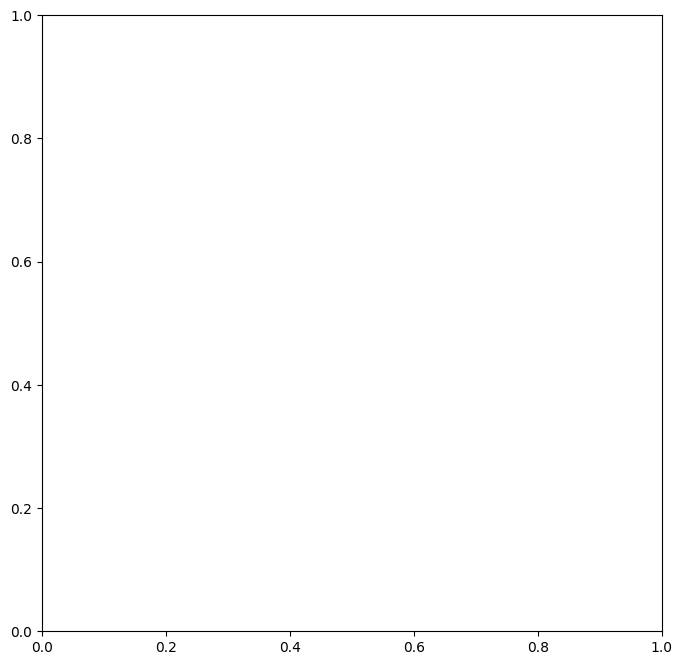

In [ ]:
# Plot and RGB Real Color Image for a single date
fig, ax = plt.subplots(figsize=(8, 8))
xx.isel(time=time_slice)[["red", "green", "blue"]].to_array().plot.imshow(robust=True, ax=ax, vmin=0, vmax=0.3)
ax.set_title("RGB Real Color")
ax.axis('off')
plt.show()

## Apply Cloud Filtering and Masking

Cloud masking for Landsat Collection-2 Level-2 data can be complicated. The **"qa_pixel"**  band is used to assess each pixel and determine its cloud or water classification. The code below is credited to Mauricio Cordiero. See his webpage [HERE](https://d9-wret.s3.us-west-2.amazonaws.com/assets/palladium/production/s3fs-public/media/files/LSDS-1619_Landsat-8-9-C2-L2-ScienceProductGuide-v4.pdf) for a more detailed explanation of the process. Also, you can visit the Landsat-8 Collection-2 Level-2 Product Guide [HERE](https://www.usgs.gov/media/files/landsat-8-9-collection-2-level-2-science-product-guide) for more details about the cloud mask values. In the end, we are searching for clouds, cloud shadows, and water to create a mask for any given region. This will allow us to extract the "clear" pixels to assess the vegetation state.

In [ ]:
# To mask the pixels and find clouds or water, it is best to use the bit values of the 16-bit qa_pixel flag
# See the website above for a nice explanation of the process

bit_flags = {
            'fill': 1<<0,
            'dilated_cloud': 1<<1,
            'cirrus': 1<<2,
            'cloud': 1<<3,
            'shadow': 1<<4,
            'snow': 1<<5,
            'clear': 1<<6,
            'water': 1<<7
}

In [ ]:
# Create a function that will mask pixels with a given type

def get_mask(mask, flags_list):

    # Create the result mask filled with zeros and the same shape as the mask
    final_mask = np.zeros_like(mask)

    # Loop through the flags
    for flag in flags_list:

        # get the mask for each flag
        flag_mask = np.bitwise_and(mask, bit_flags[flag])

        # add it to the final flag
        final_mask = final_mask | flag_mask

    return final_mask > 0

In [ ]:
# Pick a single time slice to view a mask with clouds and water
sample_xx = xx.isel(time=time_slice)

In [ ]:
# Find the pixels that are no data (fill), clouds, cloud shadows, or water
my_mask = get_mask(sample_xx['qa_pixel'], ['fill', 'dilated_cloud', 'cirrus', 'cloud', 'shadow', 'water'])

In [24]:
# Define time_slice and other missing variables for plotting
import matplotlib.pyplot as plt

# Select a time slice to view (pick the first available image)
time_slice = 0  # Use the first time slice

# Also define the bit flags for cloud masking (needed for later cells)
bit_flags = {
    'fill': 1<<0,
    'dilated_cloud': 1<<1,
    'cirrus': 1<<2,
    'cloud': 1<<3,
    'shadow': 1<<4,
    'snow': 1<<5,
    'clear': 1<<6,
    'water': 1<<7
}

print(f"✅ Variables defined:")
print(f"  time_slice: {time_slice}")
print(f"  Available time slices: 0 to {len(xx.time) - 1}")
print(f"  Data shape: {xx.dims}")

✅ Variables defined:
  time_slice: 0
  Available time slices: 0 to 5
  Data shape: FrozenMappingWarningOnValuesAccess({'latitude': 557, 'longitude': 557, 'time': 6})


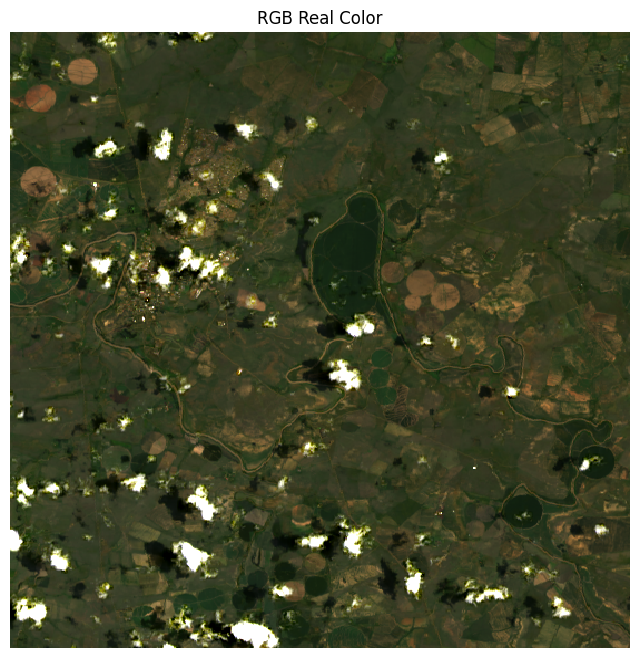

In [25]:
# Plot RGB Real Color Image for a single date
fig, ax = plt.subplots(figsize=(8, 8))
xx.isel(time=time_slice)[["red", "green", "blue"]].to_array().plot.imshow(robust=True, ax=ax, vmin=0, vmax=0.3)
ax.set_title("RGB Real Color")
ax.axis('off')
plt.show()

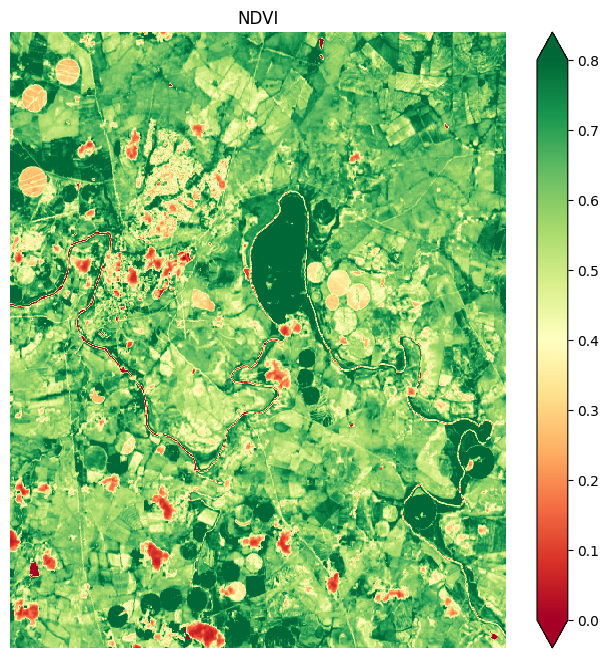

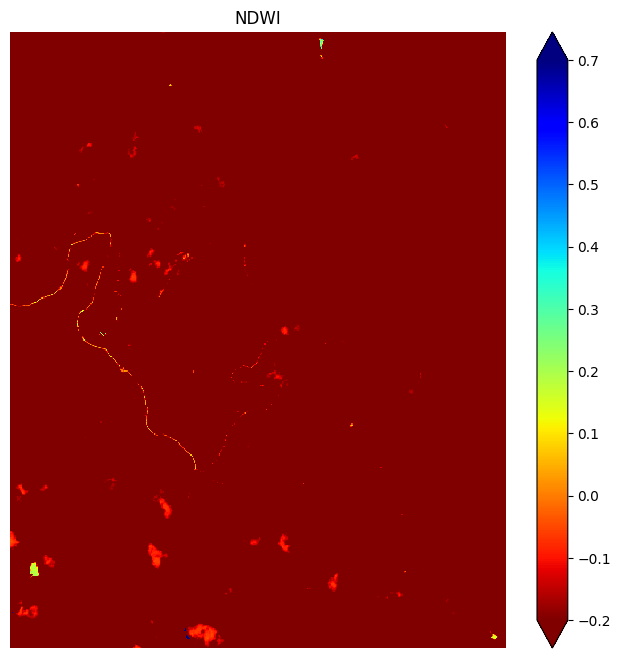

In [26]:
# Plot NDVI for the same time slice
fig, ax = plt.subplots(figsize=(8, 8))
ndvi = (xx.nir08 - xx.red) / (xx.nir08 + xx.red)
ndvi.isel(time=time_slice).plot(vmin=0.0, vmax=0.8, cmap="RdYlGn", ax=ax)
ax.set_title("NDVI")
ax.axis('off')
plt.show()

# Plot NDWI for the same time slice
fig, ax = plt.subplots(figsize=(8, 8))
ndwi = (xx.green - xx.nir08) / (xx.green + xx.nir08)
ndwi.isel(time=time_slice).plot(vmin=-0.2, vmax=0.7, cmap="jet_r", ax=ax)
ax.set_title("NDWI")
ax.axis('off')
plt.show()

### Prepare a data mask before plotting sample products

In [ ]:
# Calculate the mask for the entire xarray (all time slices)
full_mask = get_mask(xx['qa_pixel'], ['fill', 'dilated_cloud', 'cirrus', 'cloud', 'shadow', 'water'])

In [ ]:
# Create a "clean" dataset with the mask applied
cleaned_data = xx.where(~full_mask)

### Normalized Difference Vegetation Index (NDVI)

The **Normalized Difference Vegetation Index (NDVI)** is used to measure the "greenness" of vegetation and has a range of 0.0 to 1.0. Low values (0.0 to 0.25) reflect a lack of vegetation (bare soil, water), middle values (0.25 to 0.6) reflect crops in their growing state, and high values (0.6 to 1.0) reflect crops at their peak vegetation state. The equation uses two spectral bands where: **NDVI = (NIR-Red) / (NIR+Red)**.

In [ ]:
# Plot an NDVI image for a single date with few clouds
fig = plt.figure(figsize=(10, 7))
ndvi_image = (cleaned_data.nir08-cleaned_data.red)/(cleaned_data.nir08+cleaned_data.red)
ndvi_image.isel(time=time_slice).plot(vmin=0.0, vmax=0.8, cmap="RdYlGn")
plt.title("NDVI")
plt.axis('off')
plt.show()

### Normalized Difference Moisture Index (NDMI)

The **Normalized Difference Moisture Index (NDVI)** is used to measure the presence of soil moisture stress level of vegetation and has a range of -1.0 to 1.0. Higher values (0.4 to 1.0) indicate high vegetation water content, often seen in healthy, well-irrigated areas. Lower values (0 to 0.2) suggest low water content or potential water stress. Very low values (-1.0 to 0.0) typically correspond to bare soil or areas with little to no vegetation moisture. The equation uses two spectral bands where: **NDMI = (NIR-SWIR16) / (NIR+SWIR16)**.

In [ ]:
# Plot an NDMI image for a single date with few clouds
fig = plt.figure(figsize=(10, 7))
ndvi_image = (cleaned_data.nir08-cleaned_data.swir16)/(cleaned_data.nir08+cleaned_data.swir16)
ndvi_image.isel(time=time_slice).plot(vmin=-0.2, vmax=0.7, cmap="jet_r")
plt.title("NDMI")
plt.axis('off')
plt.show()

### SWIR-22 (Shortwave Infrared #2)
The Shortwave Infrared #2 band (SWIR22) has a wavelength range of 2.11 to 2.29 microns. This band is typically used for characterizing vegetation and land cover, with applications in estimating fractional crop residue cover, monitoring crop health, and distinguishing soil from vegetation. It is a critical tool for long-term land use analysis and change detection in agriculture, forestry, and coastal environments.

In [ ]:
# Plot an SWIR-22 image for a single date with few clouds
fig = plt.figure(figsize=(10, 7))
swir22_image = cleaned_data.swir22
swir22_image.isel(time=time_slice).plot(vmin=0.0, vmax=0.3, cmap="Greys")
plt.title("SWIR22")
plt.axis('off')
plt.show()

## Conclusion

Congratulations! You have successfully connected your Snowflake account to an external API, processed a variety of geospatial data, and generated complex visuals.

### We wish you and your team the best of luck in the Data Challenge!